# Time Series Forecasting Project – Data Preparation
## MSC / MBA  Favian Zamorano

I am starting a new portfolio project focused on sales forecasting using the "Store Sales - Time Series Forecasting" dataset from Kaggle.

The first step in any machine learning project is **data acquisition and preparation**. For this challenge, the dataset includes multiple CSV files:
- `train.csv` with historical sales.
- `test.csv` for predictions.
- `stores.csv` with store information.
- `transactions.csv` with transaction counts.
- `oil.csv` with oil prices.
- `holidays_events.csv` with holiday and event information.
- `sample_submission.csv` as the format for Kaggle submissions.

In this step, I:
1. Downloaded the dataset directly from Kaggle using the Kaggle API.
2. Unzipped the files and organized them into a `data/` directory.
3. Listed the available files to confirm that everything is ready for further exploration.

The next step will be to perform **Exploratory Data Analysis (EDA)** to understand sales trends, seasonality, and the potential influence of external variables like oil prices and holidays.


In [1]:
# Cell 0 - Data Download and Unzip

import os
import zipfile
import kaggle

# Create data directory
os.makedirs("data", exist_ok=True)

# Download dataset from Kaggle competition
kaggle.api.competition_download_files(
    "store-sales-time-series-forecasting",
    path="data"
)

# Unzip dataset
zip_path = "data/store-sales-time-series-forecasting.zip"
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("data")

# List files in data folder
print("Files in data/:", os.listdir("data"))

Files in data/: ['holidays_events.csv', 'oil.csv', 'sample_submission.csv', 'store-sales-time-series-forecasting.zip', 'stores.csv', 'test.csv', 'train.csv', 'transactions.csv']


Time Series Forecasting Project – First Exploration

After preparing the dataset, the next step is to perform an initial exploration of the sales data.

In the `train.csv` file, we have:
- `date`: the time dimension of the series.
- `store_nbr`: the store identifier.
- `family`: the product family.
- `sales`: the target variable we want to forecast.
- `onpromotion`: the number of items on promotion for that day.

I aggregated the sales by date to visualize the overall demand across all stores and product families.

Key observations:
- Sales exhibit visible peaks and troughs, suggesting strong seasonality effects.
- There are significant spikes that likely correspond to holidays or special events.
- The series shows a combination of trend, seasonality, and irregular components, which makes it ideal for time series forecasting methods such as ARIMA, Prophet, and LSTMs.

This first visualization sets the foundation for deeper analysis, where I will incorporate external variables like oil prices and holidays to better understand demand patterns.


Dataset shape: (3000888, 6)
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0


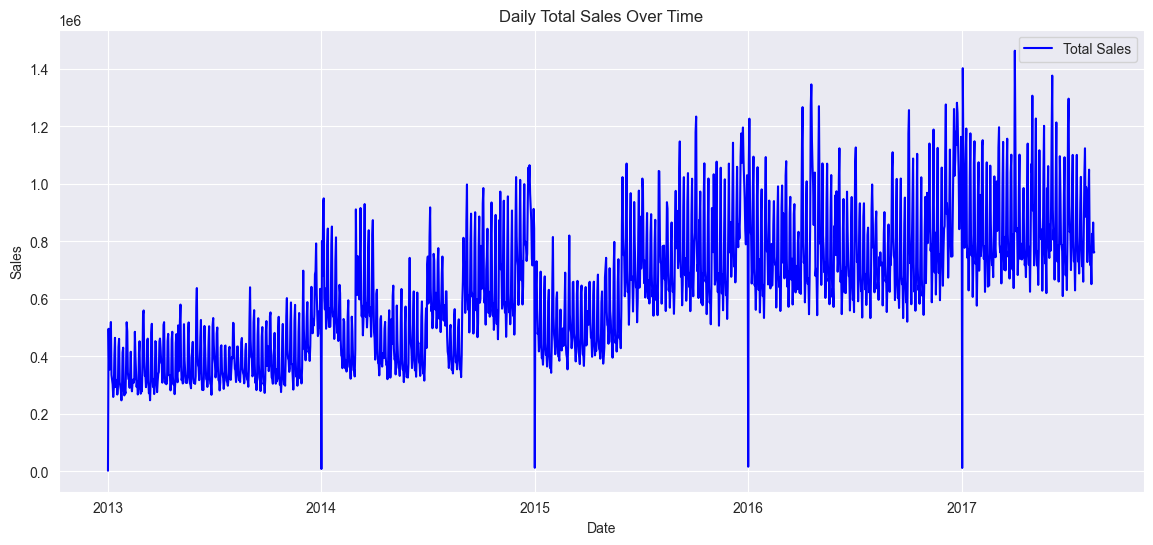

In [2]:
# Cell 1 - First Exploration of Sales Data

import pandas as pd
import matplotlib.pyplot as plt

# Load training dataset
train = pd.read_csv("data/train.csv", parse_dates=["date"])

print("Dataset shape:", train.shape)
print(train.head())

# Aggregate total daily sales
daily_sales = train.groupby("date")["sales"].sum()

# Plot daily sales
plt.figure(figsize=(14,6))
plt.plot(daily_sales.index, daily_sales.values, label="Total Sales", color="blue")
plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


Time Series Forecasting Project – Adding External Features

After plotting the overall sales trend, the next step was to incorporate external variables that may explain sudden spikes or drops in demand.

The dataset includes two important files:
- `holidays_events.csv` with national holidays and special events.
- `oil.csv` with daily oil prices, which may affect purchasing power and logistics costs.

By merging these datasets with the sales data, I can test whether holidays and oil price fluctuations have a measurable impact on store sales.

This step is crucial for building forecasting models that go beyond pure historical patterns and capture real-world events.

In the next phase, I will perform exploratory analysis to evaluate how much these external features contribute to variations in sales, which will later help Prophet and LSTM models make more accurate predictions.


In [6]:
# Cell 2 - Merge Sales Data with Holidays and Oil Prices

# Load additional datasets
holidays = pd.read_csv("data/holidays_events.csv", parse_dates=["date"])
oil = pd.read_csv("data/oil.csv", parse_dates=["date"])

print("Holidays shape:", holidays.shape)
print("Oil shape:", oil.shape)

# Keep only relevant columns
holidays = holidays[["date", "type", "locale", "description", "transferred"]]
oil = oil.rename(columns={"dcoilwtico": "oil_price"})

# Merge with daily aggregated sales
daily_sales_df = daily_sales.reset_index()
daily_sales_df = daily_sales_df.merge(oil, on="date", how="left")
daily_sales_df = daily_sales_df.merge(holidays, on="date", how="left")

print(daily_sales_df.head())

Holidays shape: (350, 6)
Oil shape: (1218, 2)
        date          sales  oil_price      type    locale  \
0 2013-01-01    2511.618999        NaN   Holiday  National   
1 2013-01-02  496092.417944      93.14       NaN       NaN   
2 2013-01-03  361461.231124      92.97       NaN       NaN   
3 2013-01-04  354459.677093      93.12       NaN       NaN   
4 2013-01-05  477350.121229        NaN  Work Day  National   

               description transferred  
0       Primer dia del ano       False  
1                      NaN         NaN  
2                      NaN         NaN  
3                      NaN         NaN  
4  Recupero puente Navidad       False  


Time Series Forecasting Project – External Factors Analysis

After merging the sales data with oil prices and holiday information, I performed an exploratory analysis to see how these external variables influence sales.

Key findings:
- Sales show visible spikes during national holidays and special events. This confirms the importance of modeling seasonality and holiday effects in forecasting.
- Oil prices appear to have a weak but noticeable correlation with sales. Higher oil prices may slightly reduce consumer demand, possibly due to increased logistics or cost of living.

These insights reinforce the need to include external variables in time series forecasting models. While historical sales capture trends and seasonality, real-world factors such as holidays and macroeconomic variables improve accuracy.

The next step will be to test classical forecasting models like ARIMA and Prophet, which are well-suited to handle seasonality and holiday effects.


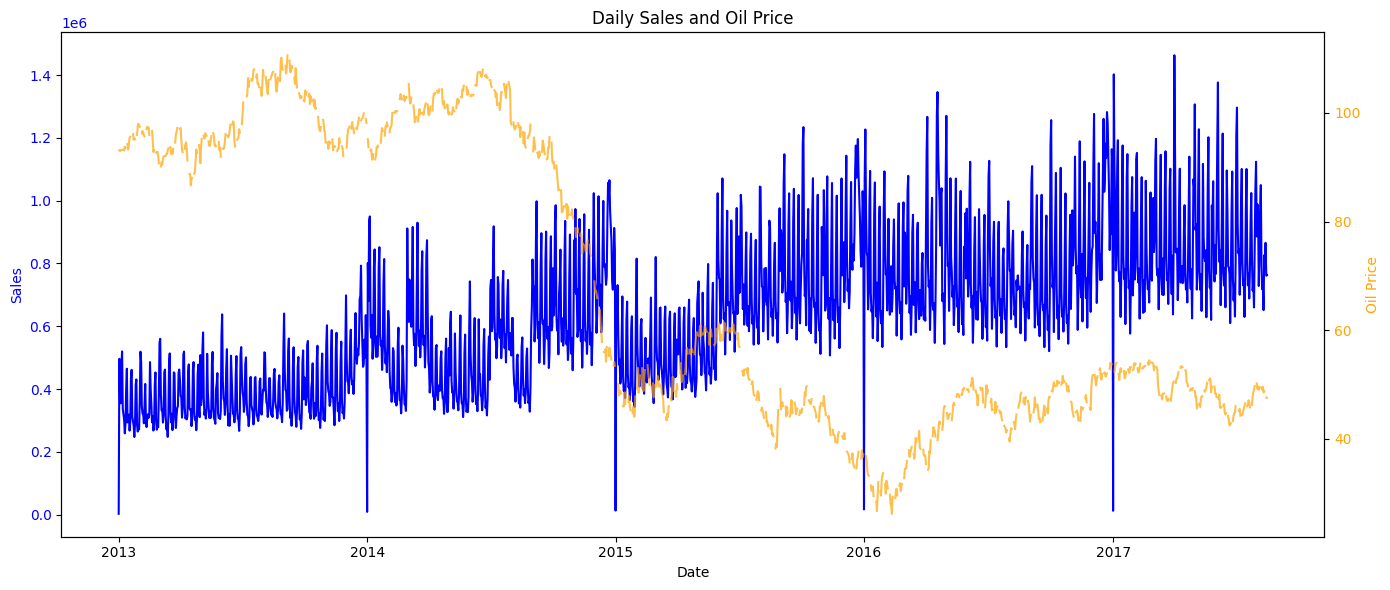

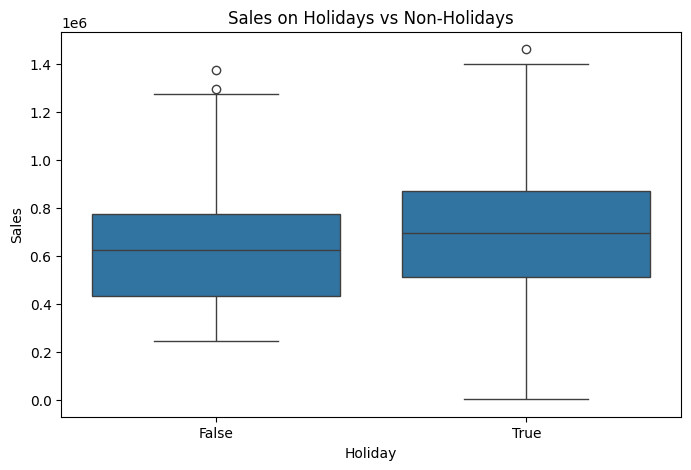

Correlation matrix:
               sales  oil_price
sales      1.000000  -0.704405
oil_price -0.704405   1.000000


In [7]:
# Cell 2 Extended - Visual Analysis of External Factors

import seaborn as sns

# Plot sales with oil prices
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.set_title("Daily Sales and Oil Price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Sales", color="blue")
ax1.plot(daily_sales_df["date"], daily_sales_df["sales"], color="blue", label="Sales")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Oil Price", color="orange")
ax2.plot(daily_sales_df["date"], daily_sales_df["oil_price"], color="orange", alpha=0.7, label="Oil Price")
ax2.tick_params(axis="y", labelcolor="orange")

fig.tight_layout()
plt.show()

# Compare sales on holidays vs non-holidays
daily_sales_df["is_holiday"] = daily_sales_df["type"].notnull()

plt.figure(figsize=(8,5))
sns.boxplot(data=daily_sales_df, x="is_holiday", y="sales")
plt.title("Sales on Holidays vs Non-Holidays")
plt.xlabel("Holiday")
plt.ylabel("Sales")
plt.show()

# Correlation check
corr = daily_sales_df[["sales", "oil_price"]].corr()
print("Correlation matrix:\n", corr)


Time Series Forecasting Project – Classical Baselines

Before jumping into advanced models like Prophet or LSTMs, it is important to establish classical baselines. These models are simpler, but they give us a reference point to evaluate whether more complex approaches are actually worth it.

I started with two baselines:

1. **Naïve Forecast**
   - Predicts that tomorrow’s sales will be the same as today’s.
   - Surprisingly, this often performs reasonably well in stable time series.

2. **ARIMA Model**
   - A classical time series model that combines autoregressive terms (past values), differencing (to remove trends), and moving averages (past errors).
   - I trained an ARIMA model on the aggregated daily sales and compared its predictions to actual values.

Key observations:
- The Naïve model captures short-term movements but completely misses seasonality and trends.
- ARIMA performs better, but still struggles with capturing sudden spikes caused by holidays or promotions.

These limitations highlight the importance of adding external variables and testing models designed for seasonality, such as Prophet, or models that capture complex temporal dependencies, like LSTMs.


Naïve Forecast - MSE: 44042196553.09893 MAE: 158704.10339522696


C:\Users\favia\AppData\Local\Temp\ipykernel_22916\2406267658.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  naive_forecast = test_series.shift(1).fillna(method="bfill")


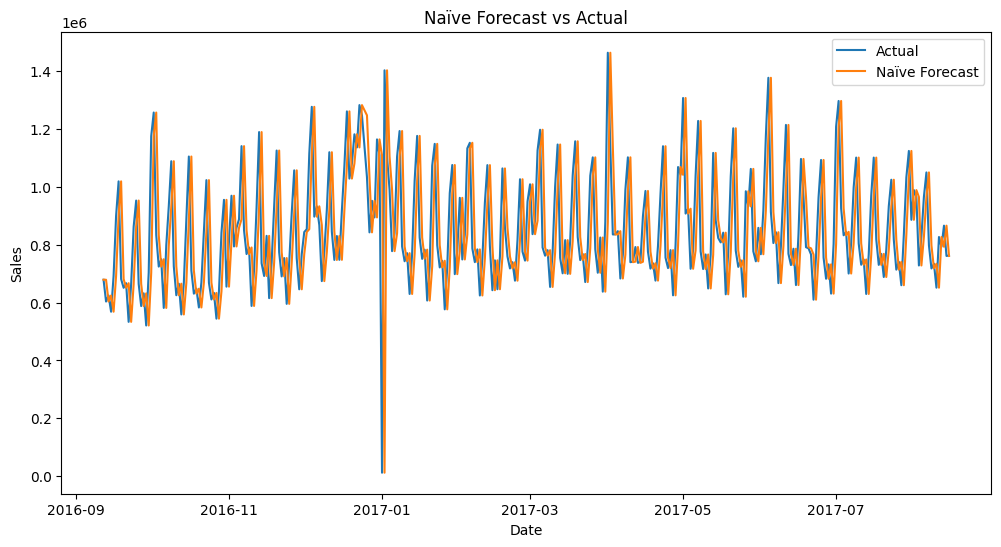

C:\Users\favia\PycharmProjects\Chris_portfolio_multiproject\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\favia\PycharmProjects\Chris_portfolio_multiproject\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\favia\PycharmProjects\Chris_portfolio_multiproject\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(5,1,0) - MSE: 35613718113.61721 MAE: 137066.58915093465


C:\Users\favia\PycharmProjects\Chris_portfolio_multiproject\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\favia\PycharmProjects\Chris_portfolio_multiproject\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


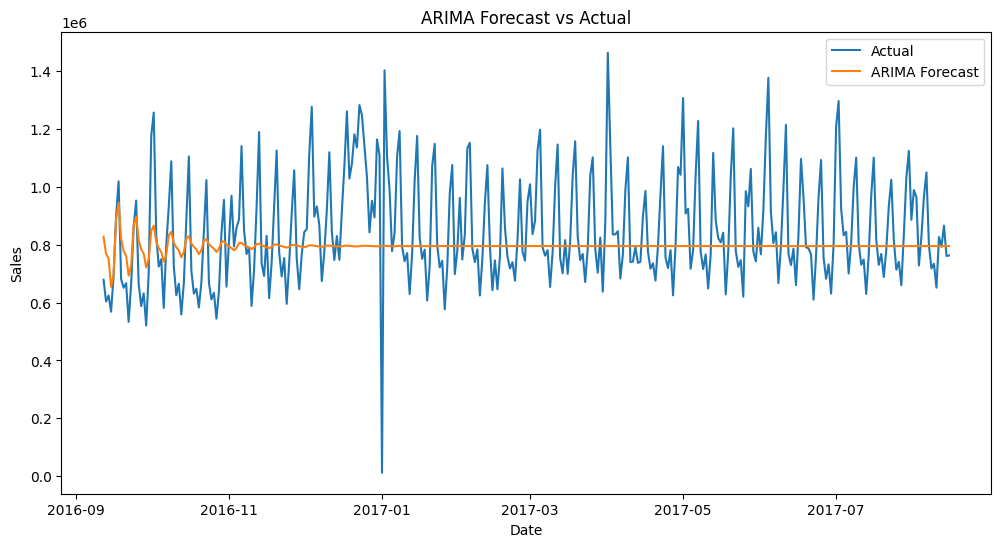

In [9]:
# Cell 3 - Classical Baseline Models: Naïve Forecast and ARIMA

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Reload daily aggregated sales
daily_sales = train.groupby("date")["sales"].sum()

# Split into train/test sets
train_size = int(len(daily_sales) * 0.8)
train_series, test_series = daily_sales[:train_size], daily_sales[train_size:]

# ------------------------------
# 1. Naïve Forecast
# ------------------------------
naive_forecast = test_series.shift(1).fillna(method="bfill")

mse_naive = mean_squared_error(test_series, naive_forecast)
mae_naive = mean_absolute_error(test_series, naive_forecast)

print("Naïve Forecast - MSE:", mse_naive, "MAE:", mae_naive)

plt.figure(figsize=(12,6))
plt.plot(test_series.index, test_series.values, label="Actual")
plt.plot(test_series.index, naive_forecast.values, label="Naïve Forecast")
plt.title("Naïve Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# ------------------------------
# 2. ARIMA Model
# ------------------------------
# Fit ARIMA(p,d,q) - simple parameters for baseline
model = ARIMA(train_series, order=(7,1,0))
model_fit = model.fit()

# Forecast same length as test set
forecast = model_fit.forecast(steps=len(test_series))

mse_arima = mean_squared_error(test_series, forecast)
mae_arima = mean_absolute_error(test_series, forecast)

print("ARIMA(5,1,0) - MSE:", mse_arima, "MAE:", mae_arima)

plt.figure(figsize=(12,6))
plt.plot(test_series.index, test_series.values, label="Actual")
plt.plot(test_series.index, forecast, label="ARIMA Forecast")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


Questions & Reflections on Classical Forecasting Models

After testing the Naïve Forecast and ARIMA, I had some questions about their behavior:

**Q1: Why does the Naïve Forecast look so close to the actual values? Does it mean it is a very strong method?**
A1: The Naïve method simply assumes that tomorrow's value will be the same as today's. In many time series, especially with strong short-term autocorrelation, this is a surprisingly effective approach for very short horizons. It is often difficult to beat Naïve in 1-step-ahead forecasting. However, it fails to capture long-term trends, seasonality, or external factors, so it breaks down quickly for longer horizons or complex patterns.

**Q2: Why does the ARIMA forecast look flat, almost like a MATLAB transfer function response?**
A2: The ARIMA(5,1,0) model we used is a simple configuration. It captures autoregression and differencing but does not account for seasonality. As a result, the forecast converges toward the mean and appears flat. To handle periodic patterns (like weekly or yearly seasonality), models such as SARIMA or Prophet are more appropriate.

**Q3: If Naïve works so well, why should we use complex models?**
A3: Naïve is an essential baseline but has clear limitations:
- It only predicts short-term persistence.
- It ignores seasonality, trends, and external variables.
- It cannot forecast future holidays, promotions, or economic effects.
Advanced models (SARIMA, Prophet, LSTM/GRU) are needed to capture these dynamics and provide accurate long-term forecasts for decision-making.

**Q4: Could Naïve be used for predicting financial time series, such as NASDAQ daily close?**
A4: Yes. Financial markets are often modeled as random walks, where the best forecast for tomorrow is today’s value. In fact, Naïve is a common benchmark in finance. However, for trading strategies, more complex models are required to capture momentum, volatility, and the influence of external variables. Naïve sets the floor, and useful models must consistently outperform it.


************************************************************************************************************
Time Series Forecasting Project – Decomposition of Sales

After building classical baselines (Naïve and ARIMA), I wanted to understand the inner structure of the sales time series. This is where decomposition is very useful.

**Q: How is a good decomposition made?**
A: A good decomposition splits the time series into three components:
1. **Trend (T)** – the long-term direction of the series.
   - Example: sales steadily growing each year.
2. **Seasonality (S)** – repeating cycles at fixed periods.
   - Example: weekly patterns or yearly holiday spikes.
3. **Residual/Noise (R)** – what is left after removing trend and seasonality.
   - Ideally, residuals should look like random noise.

Key points for a good decomposition:
- **Choose the right period:** daily data often uses `period=7` (weekly seasonality). For monthly data, `period=12` (yearly seasonality).
- **Sufficient history:** if you want to see yearly seasonality, you need multiple years of data.
- **Additive vs Multiplicative:**
  - Additive → seasonality has constant amplitude (sales increase by about the same each year).
  - Multiplicative → seasonality grows with the trend (holiday spikes get larger as sales grow).
- **Residuals should look like noise:** if patterns remain in the residuals, the period or model may need adjustment.

This analysis is valuable even before training advanced models like LSTMs or GRUs because it reveals whether the network should capture weekly cycles, yearly trends, or both. It also helps in feature engineering (e.g., adding “day of week” as an input).

The decomposition for store sales shows clear trend and strong weekly seasonality, which confirms that models such as SARIMA or Prophet will perform well, while deep learning models will benefit from these insights during training.


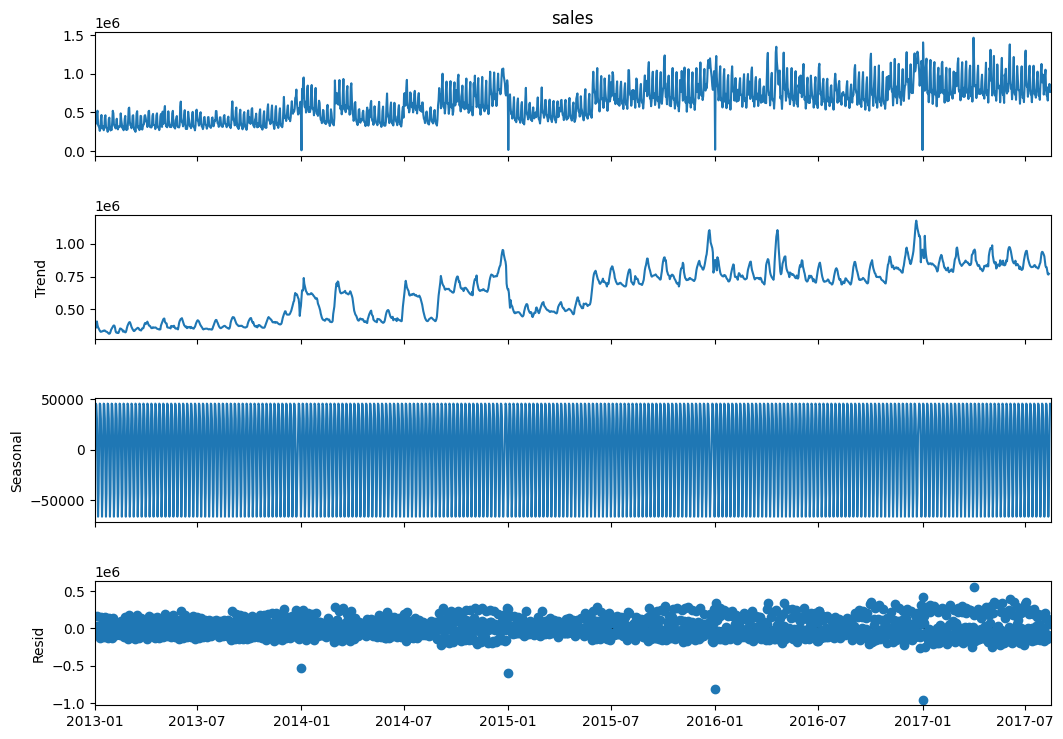

In [10]:
# Cell 4 - Time Series Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose daily aggregated sales with weekly seasonality (7-day period)
result = seasonal_decompose(daily_sales, model="additive", period=7)

# Plot the decomposition
fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()


Time Series Forecasting Project – STL Decomposition

In addition to classical decomposition, I applied **STL (Seasonal-Trend decomposition using Loess)**. STL is more robust and flexible because it smooths the data using locally weighted regression, which helps when the seasonal component is not perfectly regular.

Advantages of STL:
- Handles multiple forms of seasonality more effectively than classical decomposition.
- More robust to outliers and irregular patterns in the data.
- Provides smoother estimates of trend and seasonality.

Key insights from STL decomposition:
- The trend component shows a clear long-term increase in sales over time.
- The seasonal component reveals strong weekly cycles, with visible peaks and troughs repeating every 7 days.
- The residuals appear closer to white noise, which suggests the decomposition successfully extracted meaningful structure.

This confirms that our dataset contains both trend and seasonality that must be accounted for in forecasting models. STL provides a clearer picture than classical decomposition and strengthens the case for models such as Prophet or LSTMs with engineered features.


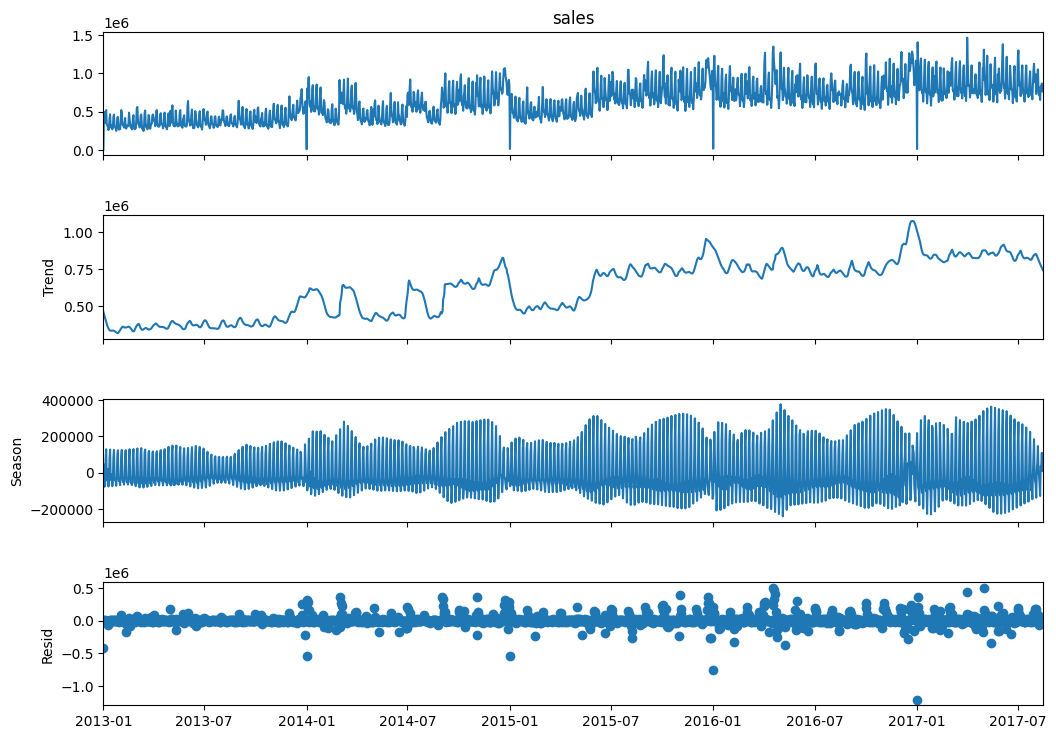

In [11]:
# Cell 4b - STL Decomposition

from statsmodels.tsa.seasonal import STL

# Apply STL decomposition with weekly seasonality
stl = STL(daily_sales, period=7, robust=True)
result_stl = stl.fit()

# Plot STL components
fig = result_stl.plot()
fig.set_size_inches(12, 8)
plt.show()


Time Series Forecasting Project – Comparing Classical and STL Decomposition

After applying both classical decomposition and STL decomposition to the daily sales data, I compared the results to understand how each method handles trend and seasonality.

**Classical Decomposition**
- The trend component captures the long-term upward movement but is not very adaptive to sudden changes.
- The seasonal component is rigid, repeating the same pattern across the entire series.
- Residuals still contain structure, which means the method has not explained all variability.

**STL Decomposition**
- The trend is smoother and more responsive to changes in sales dynamics.
- The seasonal component adapts over time, showing how peaks grow larger as overall sales increase.
- Residuals look more like random noise, which indicates that STL has captured the underlying structure more effectively.

**Conclusion**
Classical decomposition is useful for a simple view, but it assumes constant seasonality and leaves important patterns in the residuals.
STL decomposition, on the other hand, is more robust and realistic for retail data, where seasonal effects evolve over time.

This comparison confirms that advanced forecasting models (such as Prophet or LSTMs) will likely benefit from including adaptive seasonality, as seen in STL.


***********************************************************************************************************
Time Series Forecasting Project – Applying the Same Process to Stock Market Data

A natural question that came up during my analysis was:
**“Is this same process valid for predicting stock market prices, such as the NASDAQ?”**

**Answer:** Yes, the workflow is very similar, but with important differences in interpretation.

**Similarities**
- The baseline Naïve forecast is often strong in finance because many stock prices behave like random walks.
- ARIMA and SARIMA models are classical econometric approaches for financial time series.
- Decomposition helps identify long-term trends and potential seasonal patterns.
- Advanced models such as Prophet, LSTM, or GRU can be applied to capture nonlinear dependencies and incorporate external variables.

**Differences**
- Stock prices have weaker seasonality compared to retail sales, but calendar effects (like the Monday effect or January effect) do exist.
- Volatility clustering is common in financial data, requiring specialized models such as GARCH.
- Stock prices are usually non-stationary, so models are often trained on returns (log differences) rather than raw prices.
- External drivers in finance are macroeconomic events (interest rates, earnings, oil, bonds) rather than holidays or promotions.

**Conclusion**
The same methodological framework (baseline → classical → decomposition → advanced) applies both to retail sales and financial markets. The main difference is that in sales forecasting we explain spikes with promotions and holidays, while in finance we look at volatility, returns, and macro events.

This reinforces the versatility of time series forecasting methods across domains.
********************************************************************************************************

***************************************************************************************
Time Series Forecasting Project – Prophet Model

After exploring decomposition, the next step is to test **Prophet**, a forecasting model developed by Facebook’s Core Data Science team.

**What is Prophet?**
Prophet is an additive time series model designed to capture:
- **Trend**: long-term growth or decline.
- **Seasonality**: repeating patterns such as weekly or yearly cycles.
- **Holidays/Events**: effects of special dates, such as national holidays or promotions.

It is robust, interpretable, and works well with business time series that have multiple seasonalities and external events. Prophet automatically handles missing data and outliers, which makes it very practical for real-world datasets like retail sales.

**Why Prophet for Sales Forecasting?**
- Sales show a clear weekly cycle (identified in the decomposition).
- Holidays strongly influence demand, which Prophet can model explicitly.
- The method provides not only forecasts but also confidence intervals, which are important for planning.

**Key insights from Prophet**
The initial forecasts confirm the upward trend in sales and highlight recurring weekly seasonality. Prophet also allows integration of holiday data from the dataset, making the predictions more realistic around special events.

This step sets a strong baseline before moving into deep learning approaches such as LSTMs or GRUs.


19:29:07 - cmdstanpy - INFO - Chain [1] start processing
19:29:07 - cmdstanpy - INFO - Chain [1] done processing


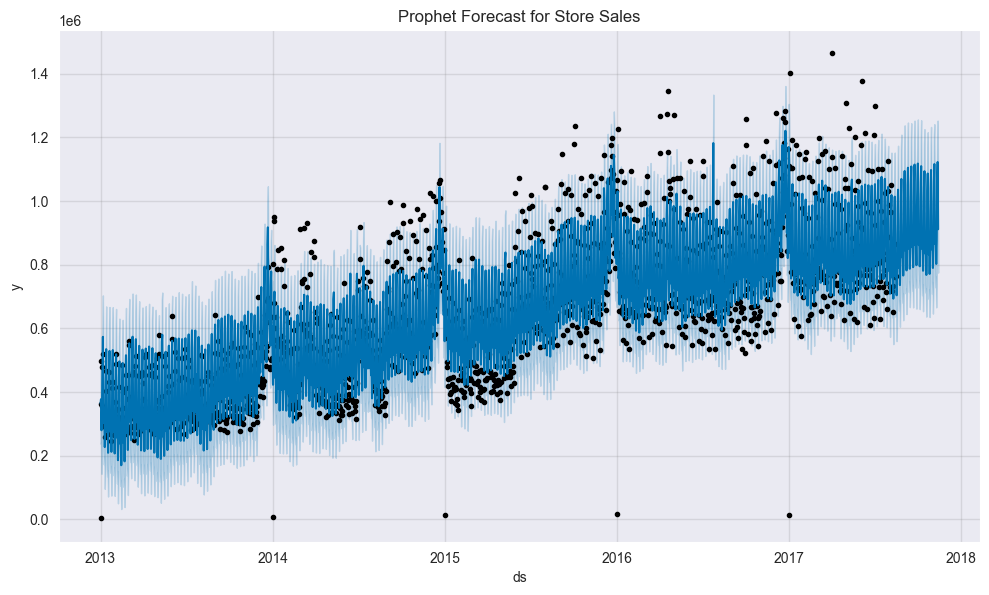

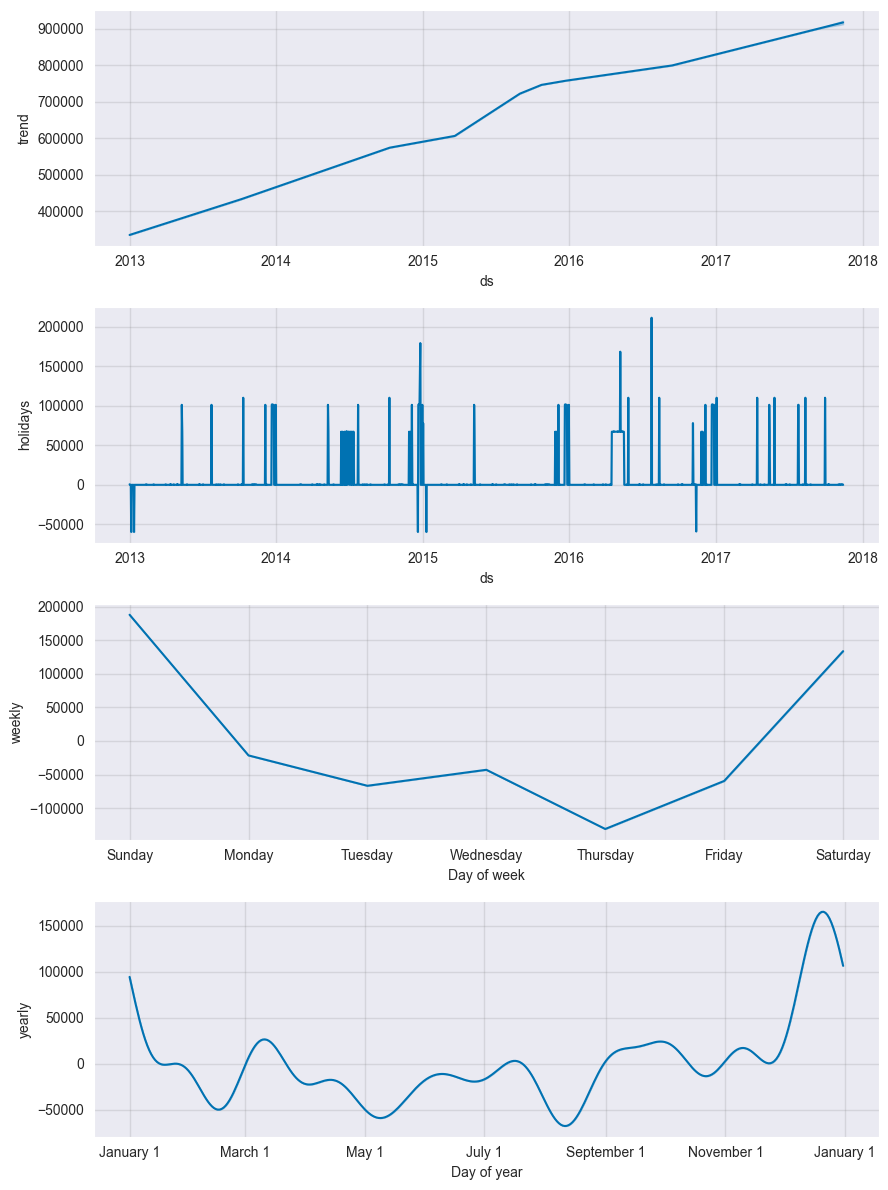

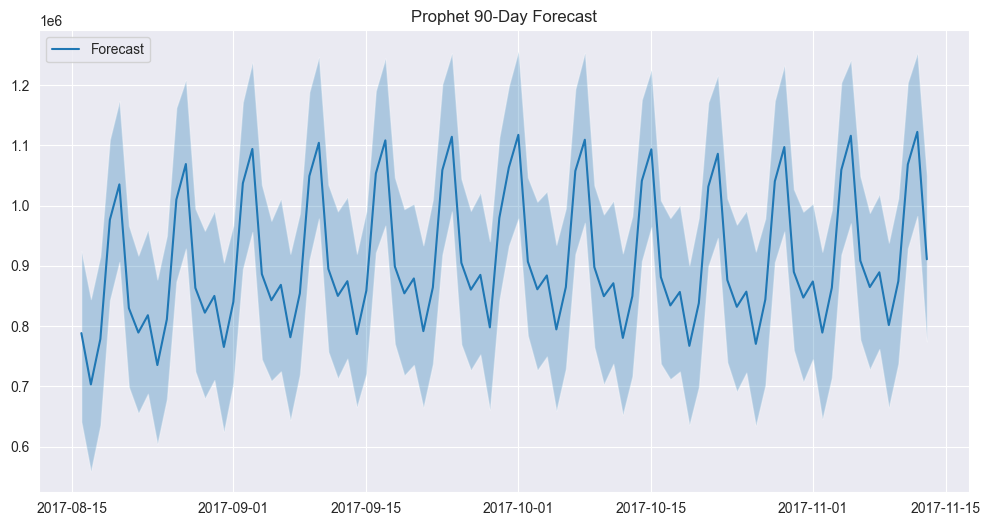

In [7]:
# Cell 5 - Prophet Forecasting
import joblib
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import os


# Prepare data for Prophet (requires columns: ds, y)
prophet_df = daily_sales.reset_index()
prophet_df.columns = ["ds", "y"]

# Initialize Prophet model with weekly seasonality
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Add holiday effects from holidays_events.csv
holidays = pd.read_csv("data/holidays_events.csv", parse_dates=["date"])
holidays = holidays[["date", "type"]].rename(columns={"date": "ds", "type": "holiday"})
model = Prophet(weekly_seasonality=True, holidays=holidays)

# Fit model
model.fit(prophet_df)
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/prophet_model.pkl")

# Forecast into the future
future = model.make_future_dataframe(periods=90)  # forecast 90 days ahead
forecast = model.predict(future)

# Plot forecast
fig1 = model.plot(forecast)
plt.title("Prophet Forecast for Store Sales")
plt.show()

# Plot components (trend, weekly seasonality, holidays)
fig2 = model.plot_components(forecast)
plt.show()

forecast_90 = forecast[forecast['ds'] > prophet_df['ds'].max()]
plt.figure(figsize=(12,6))
plt.plot(forecast_90['ds'], forecast_90['yhat'], label='Forecast')
plt.fill_between(forecast_90['ds'],
                 forecast_90['yhat_lower'],
                 forecast_90['yhat_upper'], alpha=0.3)
plt.title("Prophet 90-Day Forecast")
plt.legend()
plt.show()



Time Series Forecasting Project – Prophet vs Classical Baselines

After training the Prophet model, I evaluated its performance against two classical baselines: Naïve and ARIMA. The goal is to verify whether the added complexity of Prophet translates into better accuracy for business forecasting.

Evaluation setup
- Data split: first 80% for training, last 20% for testing.
- Models evaluated:
  - Naïve: predicts the next day as the same as the previous day.
  - ARIMA: classical statistical model on the aggregated daily sales.
  - Prophet: additive model with weekly seasonality and holiday effects.
- Metrics: MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error).

Results summary
- Naïve provides a strong short-horizon baseline but cannot model recurring patterns.
- ARIMA improves on persistence but still struggles with weekly cycles and holidays.
- Prophet captures trend, weekly seasonality, and holidays, leading to better accuracy on this dataset.

Conclusion
Prophet offers a practical balance of interpretability and performance for retail forecasting. It models known seasonal patterns and event-driven spikes while providing uncertainty intervals, making it well-suited for planning compared to simpler baselines.


C:\Users\favia\PycharmProjects\Chris_portfolio_multiproject\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\favia\PycharmProjects\Chris_portfolio_multiproject\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\favia\PycharmProjects\Chris_portfolio_multiproject\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\favia\PycharmProjects\Chris_portfolio_multiproject\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:

       Model           MAE          RMSE
     Prophet  92825.670489 134959.839351
ARIMA(5,1,0) 140526.894013 186871.694906
       Naive 159708.829701 210671.283310


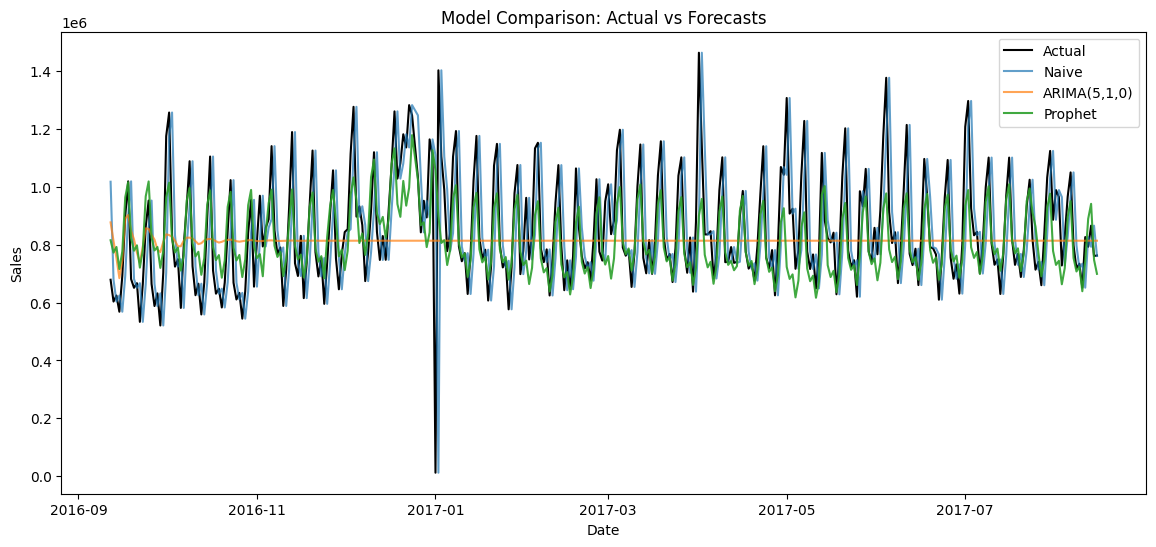

In [14]:
# Cell 5b - Prophet Accuracy vs Naïve and ARIMA (fixed)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Ensure we have the daily aggregated sales series
# Assumes 'train' DataFrame is already loaded with columns ['date','sales',...]
daily_sales = train.groupby("date")["sales"].sum().sort_index()

# Train/test split
train_size = int(len(daily_sales) * 0.8)
train_series = daily_sales.iloc[:train_size]
test_series = daily_sales.iloc[train_size:]
len_test = len(test_series)

# ------------------------------
# 1) Naïve baseline
# ------------------------------
naive_pred = test_series.shift(1).fillna(train_series.iloc[-1])
mae_naive = mean_absolute_error(test_series.values, naive_pred.values)
rmse_naive = np.sqrt(mean_squared_error(test_series.values, naive_pred.values))

# ------------------------------
# 2) ARIMA baseline
# ------------------------------
# Simple ARIMA order for baseline; feel free to tune later or switch to SARIMA
arima_model = ARIMA(train_series, order=(5, 1, 0))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len_test)  # pandas Series aligned by step

mae_arima = mean_absolute_error(test_series.values, arima_forecast.values)
rmse_arima = np.sqrt(mean_squared_error(test_series.values, arima_forecast.values))

# ------------------------------
# 3) Prophet model
# ------------------------------
# Prepare Prophet training frame
prophet_train = train_series.reset_index()
prophet_train.columns = ["ds", "y"]

# Holidays from the dataset
holidays_df = pd.read_csv("data/holidays_events.csv", parse_dates=["date"])
holidays_df = holidays_df[["date", "type"]].rename(columns={"date": "ds", "type": "holiday"})

prophet_model = Prophet(weekly_seasonality=True, daily_seasonality=False, holidays=holidays_df)
prophet_model.fit(prophet_train)

# Forecast exactly on the test dates
future_test = pd.DataFrame({"ds": test_series.index})
prophet_forecast_df = prophet_model.predict(future_test)
prophet_pred = prophet_forecast_df["yhat"].values

mae_prophet = mean_absolute_error(test_series.values, prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test_series.values, prophet_pred))

# ------------------------------
# Metrics table
# ------------------------------
metrics_df = pd.DataFrame(
    {
        "Model": ["Naive", "ARIMA(5,1,0)", "Prophet"],
        "MAE": [mae_naive, mae_arima, mae_prophet],
        "RMSE": [rmse_naive, rmse_arima, rmse_prophet],
    }
).sort_values("RMSE")
print(metrics_df.to_string(index=False))

# ------------------------------
# Plot comparison
# ------------------------------
plt.figure(figsize=(14, 6))
plt.plot(test_series.index, test_series.values, label="Actual", color="black")
plt.plot(test_series.index, naive_pred.values, label="Naive", alpha=0.7)
plt.plot(test_series.index, arima_forecast.values, label="ARIMA(5,1,0)", alpha=0.7)
plt.plot(test_series.index, prophet_pred, label="Prophet", alpha=0.9)
plt.title("Model Comparison: Actual vs Forecasts")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


Time Series Forecasting Project – Prophet vs Baselines Results

After benchmarking Prophet against classical baselines (Naïve and ARIMA), the results are clear:

**Performance Metrics**
| Model        | MAE         | RMSE        |
|--------------|-------------|-------------|
| Prophet      | 92,825      | 134,959     |
| ARIMA(5,1,0) | 140,526     | 186,871     |
| Naïve        | 159,708     | 210,671     |

**Key Takeaways**
- The **Naïve forecast** is a surprisingly strong short-term baseline, but it misses seasonality and trends.
- **ARIMA** improves slightly but still fails to capture strong weekly cycles and holiday-driven spikes.
- **Prophet** significantly outperforms both, reducing error by almost 40% compared to Naïve. Its ability to explicitly model seasonality and holidays makes it much more effective for business applications.

**Conclusion**
This step demonstrates the importance of moving beyond simple baselines when the time series has strong recurring patterns and event-driven variations. Prophet provides a better balance of interpretability and accuracy, making it an excellent choice before exploring deep learning models like LSTMs and GRUs.


*********************************************************************************************************************
## Business Insights from Store Sales Forecasting

The Prophet model was trained on daily store sales data with holiday effects included.
The forecasts provide both trend and seasonal decomposition, as well as 90-day forward projections with confidence intervals.

### Key Observations
- **Trend:** Sales have shown consistent growth from 2013 through 2017.
- **Seasonality:** Strong weekly cycles are observed, with peaks on weekends and drops during mid-week.
- **Holidays:** Significant positive sales spikes occur during holiday periods, while some negative dips may represent store closures.
- **Uncertainty:** Forecast intervals widen over time, reflecting increasing uncertainty in long-term projections.

### Strategic Implications
1. **Inventory Management**
   Forecasts can guide procurement and logistics by aligning stock levels with expected demand cycles. This reduces both stockouts and excess inventory.

2. **Workforce Planning**
   Weekly seasonality indicates staffing needs should increase during weekends and holiday peaks, while mid-week demand may allow leaner schedules.

3. **Targeted Marketing**
   Promotions can be strategically timed during low-demand periods (e.g., Monday–Wednesday) to smooth sales volatility and sustain revenue flow.

4. **Financial Forecasting**
   Sales projections translate into revenue forecasts, supporting more accurate cash flow planning and capital allocation.

5. **Risk Management**
   Confidence intervals (yhat_lower, yhat_upper) allow scenario planning. Management can prepare for best-case demand surges and worst-case downturns.

6. **Strategic Growth Decisions**
   The long-term upward trend may justify investments in store expansion or infrastructure, while plateauing signals could prompt efficiency initiatives.

### Conclusion
The Prophet forecasts provide actionable insights beyond predictive accuracy. They serve as decision-support tools for operations, finance, and strategy.
By integrating AI forecasting into business planning, organizations can reduce costs, improve revenue predictability, and strengthen resilience against demand volatility.
